In [1]:
import pandas as pd
import glob

In [2]:
files = glob.glob("../data/attendance_day*.xlsx")
files

['../data\\attendance_day1.xlsx.xlsx',
 '../data\\attendance_day2.xlsx.xlsx',
 '../data\\attendance_day3.xlsx.xlsx',
 '../data\\attendance_day4.xlsx.xlsx']

In [3]:
df_list = []

for file in files:
    data = pd.read_excel(file)
    df_list.append(data)

attendance = pd.concat(df_list, ignore_index=True)

In [4]:
attendance.head()

,Date,Student_ID,Subject,Status
0,2025-02-01,S001,Machine Learning,Present
1,2025-02-01,S002,Machine Learning,Absent
2,2025-02-01,S003,Machine Learning,Present
3,2025-02-01,S004,Machine Learning,Present
4,2025-02-01,S005,Machine Learning,Absent


In [5]:
attendance.shape

(24, 4)

In [6]:
students = pd.read_csv("../data/students.csv")
students.head()

,Student_ID,Name,College,Department,Year
0,S001,Ravi,ABC,CSE,3
1,S002,Sneha,XYZ,ECE,2
2,S003,Rahul,ABC,ME,3
3,S004,Priya,LMN,CSE,4
4,S005,Amit,ABC,CSE,2


In [7]:
df = attendance.merge(students, on="Student_ID")
df.head()

,Date,Student_ID,Subject,Status,Name,College,Department,Year
0,2025-02-01,S001,Machine Learning,Present,Ravi,ABC,CSE,3
1,2025-02-01,S002,Machine Learning,Absent,Sneha,XYZ,ECE,2
2,2025-02-01,S003,Machine Learning,Present,Rahul,ABC,ME,3
3,2025-02-01,S004,Machine Learning,Present,Priya,LMN,CSE,4
4,2025-02-01,S005,Machine Learning,Absent,Amit,ABC,CSE,2


In [8]:
df["Present"] = df["Status"].apply(lambda x: 1 if x == "Present" else 0)

In [9]:
df.head()

,Date,Student_ID,Subject,Status,Name,College,Department,Year,Present
0,2025-02-01,S001,Machine Learning,Present,Ravi,ABC,CSE,3,1
1,2025-02-01,S002,Machine Learning,Absent,Sneha,XYZ,ECE,2,0
2,2025-02-01,S003,Machine Learning,Present,Rahul,ABC,ME,3,1
3,2025-02-01,S004,Machine Learning,Present,Priya,LMN,CSE,4,1
4,2025-02-01,S005,Machine Learning,Absent,Amit,ABC,CSE,2,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        24 non-null     object
 1   Student_ID  24 non-null     object
 2   Subject     24 non-null     object
 3   Status      24 non-null     object
 4   Name        24 non-null     object
 5   College     24 non-null     object
 6   Department  24 non-null     object
 7   Year        24 non-null     int64 
 8   Present     24 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 1.8+ KB


In [11]:
attendance_rate = df.groupby("Student_ID")["Present"].mean() * 100
attendance_rate

Student_ID
S001    75.0
S002    50.0
S003    75.0
S004    75.0
S005    75.0
S006    50.0
Name: Present, dtype: float64

In [12]:
low_attendance = attendance_rate[attendance_rate < 75]
low_attendance

Student_ID
S002    50.0
S006    50.0
Name: Present, dtype: float64

In [13]:
dept_attendance = df.groupby("Department")["Present"].mean() * 100
dept_attendance

Department
CSE    75.0
ECE    50.0
ME     75.0
Name: Present, dtype: float64

In [14]:
college_attendance = df.groupby("College")["Present"].mean() * 100
college_attendance

College
ABC    75.0
LMN    75.0
XYZ    50.0
Name: Present, dtype: float64

In [15]:
subject_attendance = df.groupby("Subject")["Present"].mean() * 100
subject_attendance

Subject
Deep Learning       66.666667
Machine Learning    66.666667
Python              66.666667
Name: Present, dtype: float64

In [16]:
daily_attendance = df.groupby("Date")["Present"].mean() * 100
daily_attendance

Date
2025-02-01    66.666667
2025-02-02    66.666667
2025-02-03    66.666667
2025-02-04    66.666667
Name: Present, dtype: float64

In [18]:
class_attendance = df.groupby(["Date","Subject"])["Present"].mean() * 100

low_classes = class_attendance[class_attendance < 50]
low_classes

Series([], Name: Present, dtype: float64)

In [19]:
import matplotlib.pyplot as plt

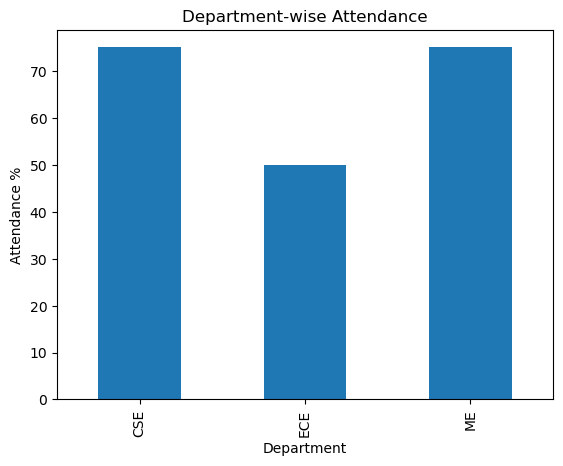

In [20]:
dept_attendance.plot(kind='bar')
plt.title("Department-wise Attendance")
plt.xlabel("Department")
plt.ylabel("Attendance %")
plt.show()

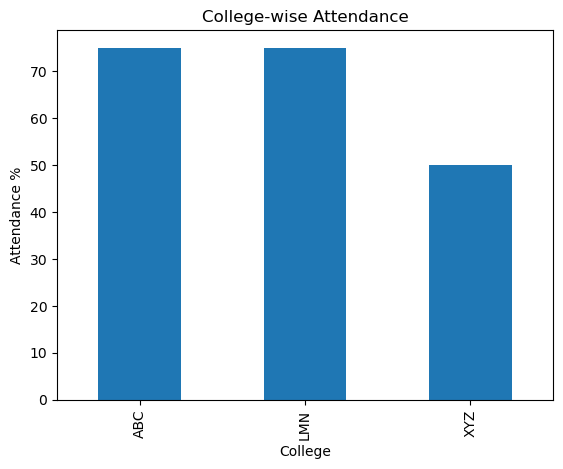

In [21]:
college_attendance.plot(kind='bar')
plt.title("College-wise Attendance")
plt.xlabel("College")
plt.ylabel("Attendance %")
plt.show()

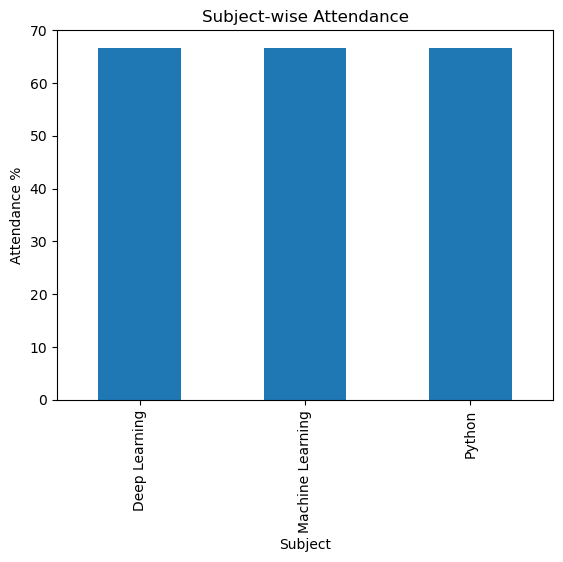

<Figure size 640x480 with 0 Axes>

In [26]:
subject_attendance.plot(kind='bar')
plt.title("Subject-wise Attendance")
plt.xlabel("Subject")
plt.ylabel("Attendance %")
plt.show()
plt.tight_layout()

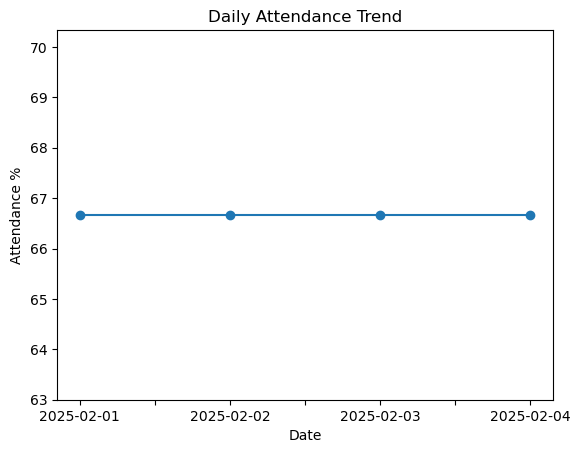

In [23]:
daily_attendance.plot(kind='line', marker='o')
plt.title("Daily Attendance Trend")
plt.xlabel("Date")
plt.ylabel("Attendance %")
plt.show()

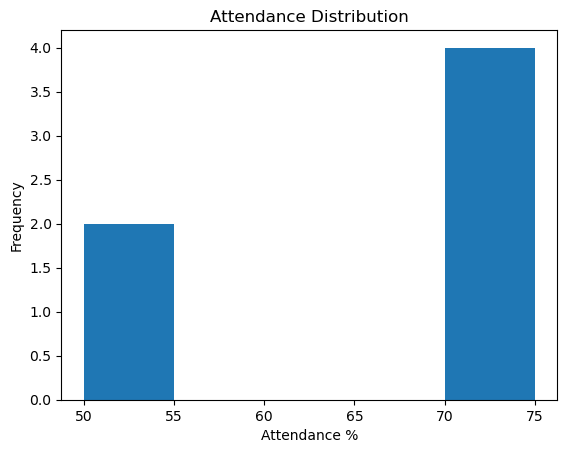

<Figure size 640x480 with 0 Axes>

In [25]:
attendance_rate.plot(kind='hist', bins=5)
plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.show()
plt.tight_layout()